# Task 1 — Classification Algorithms
**10 Points** | School of Artificial Intelligence and Data Science

---

## 1. Theoretical Summary of Six Classification Algorithms

---

### 1.1 k-Nearest Neighbors (k-NN)

**Core Idea:** k-NN is a non-parametric, instance-based (lazy) learning algorithm. During inference, it computes the distance between the query point and all training samples, selects the k closest neighbors, and assigns the majority class label. The most common distance metric is the Euclidean distance:

$$d(x, x') = \sqrt{\sum_{i=1}^{n}(x_i - x'_i)^2}$$

No explicit training phase exists — the model simply memorizes the dataset.

**Key Hyperparameters:**
- `k` (number of neighbors): small k → complex boundary (overfitting); large k → smoother boundary (underfitting)
- Distance metric: Euclidean, Manhattan, Minkowski
- Weighting: uniform or distance-weighted

**Complexity:**
- Training: O(1)
- Inference: O(n·d) where n = number of samples, d = number of features
- Space: O(n·d) — stores entire dataset

**Best Use Cases:** Small datasets, low-dimensional data, recommendation systems, anomaly detection.

**Limitations:** Very slow at inference on large datasets; highly sensitive to irrelevant features and feature scaling; suffers from the curse of dimensionality.

---

### 1.2 Decision Trees

**Core Idea:** A Decision Tree recursively partitions the feature space by selecting the feature and threshold that best splits the data according to an impurity measure. The most common measures are:

**Gini Impurity:**
$$G = 1 - \sum_{k=1}^{K} p_k^2$$

**Information Gain (Entropy-based):**
$$H = -\sum_{k=1}^{K} p_k \log_2(p_k)$$

At each node, the algorithm selects the split that maximally reduces impurity. Leaf nodes contain the majority class of samples reaching them.

**Key Hyperparameters:**
- `max_depth`: limits tree depth to prevent overfitting
- `min_samples_split`: minimum samples required to split a node
- `criterion`: 'gini' or 'entropy'

**Complexity:**
- Training: O(n·d·log n)
- Inference: O(depth)

**Best Use Cases:** Interpretable models, mixed data types, feature importance analysis.

**Limitations:** Prone to overfitting without pruning; unstable (small data changes cause large tree changes); biased toward features with many levels.

---

### 1.3 Random Forest

**Core Idea:** Random Forest is an ensemble method that builds multiple decision trees via **bootstrap aggregation (bagging)** and averages their predictions. Each tree is trained on a random subset of samples and, at each split, considers only a random subset of features. This decorrelates the trees and reduces variance:

$$\hat{y} = \text{majority\_vote}(T_1(x), T_2(x), \ldots, T_B(x))$$

**Key Hyperparameters:**
- `n_estimators`: number of trees (more = better, diminishing returns)
- `max_features`: features considered at each split (typically √d for classification)
- `max_depth`: maximum depth per tree

**Complexity:**
- Training: O(B·n·d·log n)
- Inference: O(B·depth)

**Best Use Cases:** Tabular data, feature importance ranking, datasets with mixed features.

**Limitations:** Less interpretable than a single tree; high memory usage; slower inference than single models.

---

### 1.4 Support Vector Machines (SVM)

**Core Idea:** SVM finds the **maximum-margin hyperplane** separating classes. The decision boundary is:

$$f(x) = w^T x + b = 0$$

The margin is maximized by solving the optimization problem:

$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{subject to} \quad y_i(w^T x_i + b) \geq 1$$

For non-linearly separable data, the **kernel trick** maps inputs to higher dimensions:
- RBF kernel: $K(x, x') = \exp(-\gamma \|x - x'\|^2)$

**Key Hyperparameters:**
- `C`: regularization (large C → low bias, high variance)
- `kernel`: linear, rbf, poly
- `gamma`: RBF kernel bandwidth

**Complexity:**
- Training: O(n²) to O(n³)
- Inference: O(n_sv · d) where n_sv = number of support vectors

**Best Use Cases:** High-dimensional data, text classification, image classification.

**Limitations:** Slow training on large datasets; requires careful feature scaling; kernel selection can be non-trivial.

---

### 1.5 Logistic Regression

**Core Idea:** Logistic Regression models the probability of class membership using the **sigmoid function**:

$$P(y=1|x) = \sigma(w^T x + b) = \frac{1}{1 + e^{-(w^T x + b)}}$$

Parameters are learned by minimizing the **binary cross-entropy loss**:

$$L = -\sum_{i=1}^{n} \left[ y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

Multi-class extension uses softmax and one-vs-rest or multinomial schemes.

**Key Hyperparameters:**
- `C`: inverse regularization strength
- `penalty`: 'l1', 'l2', 'elasticnet'
- `solver`: 'lbfgs', 'saga', 'liblinear'

**Complexity:**
- Training: O(n·d·iterations)
- Inference: O(d)

**Best Use Cases:** Binary and multi-class classification, interpretable probability outputs, baseline model.

**Limitations:** Assumes linear decision boundary; poor performance on complex non-linear data without feature engineering.

---

### 1.6 Naive Bayes

**Core Idea:** Naive Bayes applies **Bayes' theorem** with the strong (naive) assumption that features are conditionally independent given the class label:

$$P(y|x) \propto P(y) \prod_{i=1}^{d} P(x_i|y)$$

Classification assigns the class with the highest posterior:

$$\hat{y} = \arg\max_y P(y) \prod_{i=1}^{d} P(x_i|y)$$

Variants: Gaussian NB (continuous features), Multinomial NB (text counts), Bernoulli NB (binary features).

**Key Hyperparameters:**
- `var_smoothing` (GaussianNB): handles zero-probability issue
- `alpha` (MultinomialNB): Laplace smoothing

**Complexity:**
- Training: O(n·d)
- Inference: O(K·d) where K = number of classes

**Best Use Cases:** Text classification (spam detection), real-time prediction, very large datasets.

**Limitations:** Strong independence assumption rarely holds; can be outperformed by more sophisticated methods on structured data.

## 2. Comparison Table

| Algorithm | Interpretability | Scalability | Outlier Sensitivity | High-Dim Data | Multi-class Support |
|---|---|---|---|---|---|
| k-NN | Low | Poor (O(nd) inference) | High | Poor (curse of dim.) | Native (majority vote) |
| Decision Tree | High | Good | Moderate | Moderate | Native |
| Random Forest | Medium | Moderate | Low | Good | Native |
| SVM | Low | Poor (O(n²–n³) train) | Low (margin-based) | Excellent | One-vs-rest / OvO |
| Logistic Regression | High | Excellent | Moderate | Good (with regularization) | One-vs-rest / Softmax |
| Naive Bayes | Medium | Excellent | Moderate | Good | Native |

## 3. Algorithm Deep Dive — Random Forest

### 3.1 Mathematical Derivation

**Step 1: Bootstrap Sampling**

For each tree $T_b$ (b = 1, ..., B), draw a bootstrap sample $Z^{*b}$ of size n from the training set with replacement:

$$Z^{*b} = \{(x_{i_1}, y_{i_1}), \ldots, (x_{i_n}, y_{i_n})\}, \quad i_j \sim \text{Uniform}(1,n)$$

**Step 2: Random Feature Selection at Each Split**

At each node, select a random subset $\mathcal{F} \subset \{1, \ldots, d\}$ of size $m = \lfloor\sqrt{d}\rfloor$ features. Find the best split:

$$\text{split}^* = \arg\max_{j \in \mathcal{F}, t} \left[ G(\text{parent}) - \frac{n_L}{n}G(L) - \frac{n_R}{n}G(R) \right]$$

where $G$ is the Gini impurity, $n_L, n_R$ are the sample counts in left/right child nodes.

**Step 3: Gini Impurity Calculation**

$$G(\mathcal{D}) = 1 - \sum_{k=1}^{K} \left(\frac{|\{i: y_i = k\}|}{|\mathcal{D}|}\right)^2$$

**Step 4: Aggregation (Majority Vote)**

$$\hat{y}(x) = \arg\max_k \sum_{b=1}^{B} \mathbf{1}[T_b(x) = k]$$

**Why does it work? — Bias-Variance Decomposition:**

For B independent trees, each with variance $\sigma^2$ and pairwise correlation $\rho$:

$$\text{Var}(\bar{T}) = \rho \sigma^2 + \frac{1-\rho}{B}\sigma^2$$

As $B \to \infty$, variance approaches $\rho \sigma^2$. Random feature selection reduces $\rho$ (decorrelates trees), directly reducing ensemble variance.

---

### 3.2 Hand-Crafted Example with Manual Calculations

**Dataset:** 6 samples, 2 features (Height, Weight), Binary class (Tall/Short)

| # | Height | Weight | Class |
|---|--------|--------|-------|
| 1 | 180 | 80 | Tall |
| 2 | 165 | 60 | Short |
| 3 | 175 | 75 | Tall |
| 4 | 160 | 55 | Short |
| 5 | 170 | 70 | Tall |
| 6 | 158 | 50 | Short |

**Root node Gini (3 Tall, 3 Short):**
$$G = 1 - \left(\frac{3}{6}\right)^2 - \left(\frac{3}{6}\right)^2 = 1 - 0.25 - 0.25 = 0.5$$

**Split on Height ≥ 170:**
- Left (Height < 170): samples {2,4,6} → 0 Tall, 3 Short → $G_L = 0$
- Right (Height ≥ 170): samples {1,3,5} → 3 Tall, 0 Short → $G_R = 0$

**Information Gain:**
$$IG = 0.5 - \frac{3}{6}(0) - \frac{3}{6}(0) = 0.5$$

This is a perfect split! The tree would stop here with pure leaf nodes.

---

### 3.3 Overfitting and Underfitting Behavior

**Overfitting:** Individual deep trees in the forest overfit (zero training error), but averaging reduces this. Risk increases when `n_estimators` is too small or `max_features` is too large (trees become correlated).

**Underfitting:** Occurs when trees are too shallow (`max_depth` too small) or `n_estimators` is too small to capture data complexity.

**Optimal region:** Best performance achieved with fully grown trees (no depth limit) and a sufficient number of trees (typically 100–500). The out-of-bag (OOB) error provides an unbiased estimate without a separate validation set.

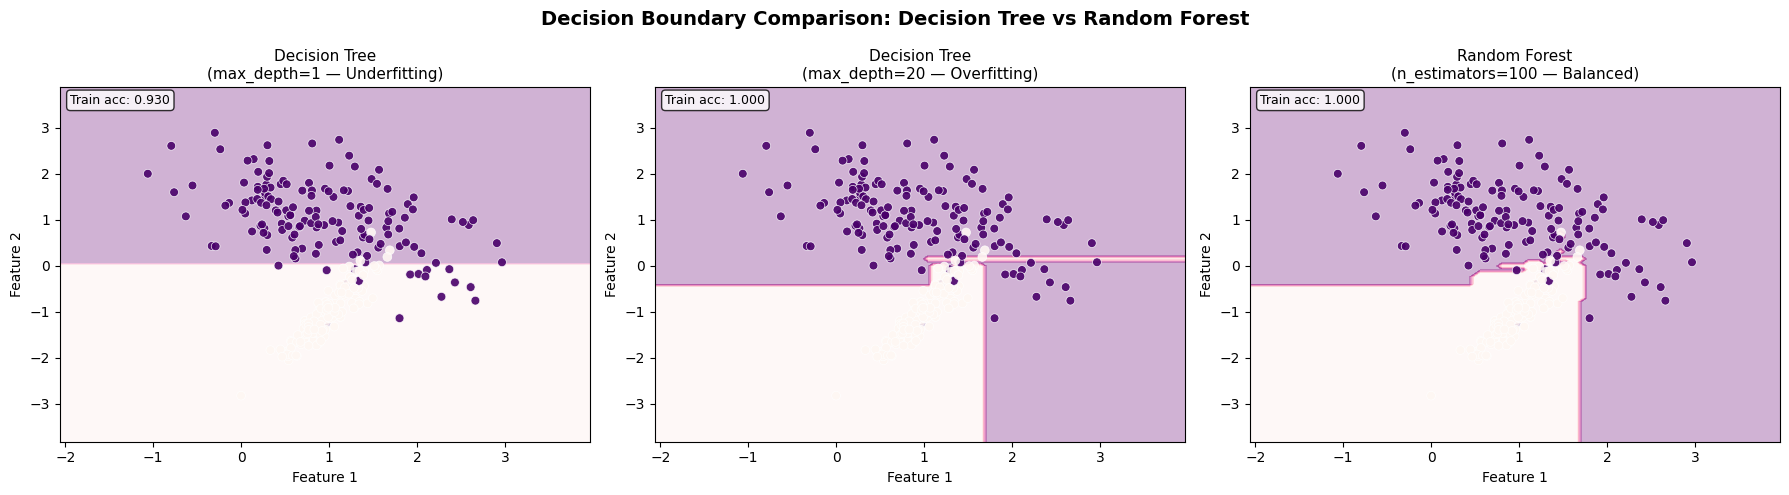

Figure saved to results/task1_decision_boundaries.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import DecisionBoundaryDisplay

# Generate 2D dataset for visualization
X, y = make_classification(
    n_samples=300, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Decision Boundary Comparison: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')

configs = [
    (DecisionTreeClassifier(max_depth=1, random_state=42), 'Decision Tree\n(max_depth=1 — Underfitting)'),
    (DecisionTreeClassifier(max_depth=20, random_state=42), 'Decision Tree\n(max_depth=20 — Overfitting)'),
    (RandomForestClassifier(n_estimators=100, random_state=42), 'Random Forest\n(n_estimators=100 — Balanced)'),
]

colors_bg = ['#EEEDFE', '#FAECE7']
colors_pt = ['#534AB7', '#993C1D']

for ax, (clf, title) in zip(axes, configs):
    clf.fit(X, y)
    DecisionBoundaryDisplay.from_estimator(
        clf, X, ax=ax, alpha=0.3,
        cmap=plt.cm.RdPu, response_method='predict'
    )
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdPu,
                         edgecolors='white', linewidths=0.5, s=40, alpha=0.9)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    train_acc = clf.score(X, y)
    ax.text(0.02, 0.98, f'Train acc: {train_acc:.3f}',
            transform=ax.transAxes, fontsize=9,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('../results/task1_decision_boundaries.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to results/task1_decision_boundaries.png')

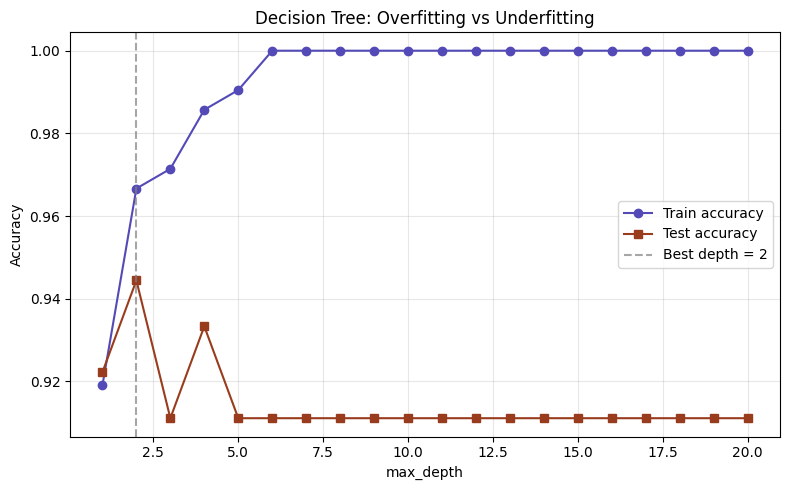

In [2]:
# Overfitting vs Underfitting analysis — varying max_depth
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

depths = range(1, 21)
train_scores, test_scores = [], []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_scores, 'o-', color='#534AB7', label='Train accuracy')
plt.plot(depths, test_scores, 's-', color='#993C1D', label='Test accuracy')
plt.axvline(x=depths[np.argmax(test_scores)], color='gray', linestyle='--', alpha=0.7,
            label=f'Best depth = {depths[np.argmax(test_scores)]}')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Overfitting vs Underfitting')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/task1_overfit_underfit.png', dpi=150, bbox_inches='tight')
plt.show()